<a href="https://colab.research.google.com/github/SangeetBarkataki10/CS105Minproject-SSTMA/blob/smadi012/SSTMA_CS105.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ETL Pipeline

In [5]:
import pandas as pd

df = pd.read_csv("CS105_data.csv")

column_mapping = {
    # Demographics
    2: "Class Standing",
    13: "Cumulative GPA",

    # AI Reliance
    42: "LLM Frequency (ChatGPT)",
    43: "LLM Frequency (Claude)",
    44: "LLM Frequency (Gemini)",
    46: "LLM Frequency (Copilot)",
    47: "LLM Frequency (Perplexity)",
    48: "LLM Frequency (Deepseek)",
    86: "Math Usage",
    88: "CS Usage",
    89: "Data Science Usage",
    99: "AI Chatbot Usage",

    # Confidence in Original Work
    53: "Coding Self Confidence",
    54: "Research Self Confidence",
    55: "Data Analysis Self Confidence",
    56: "Writing Self Confidence",
    57: "Topic Summarization Self Confidence",
    107: "Agreement",
    62: "Overreliance Concern",
    59: "Loss of Learning Concern",

    # Trust in AI vs Need for Verification
    92: "Math Trust",
    94: "CS Trust",
    95: "Data Science Trust",
    61: "Hallucinations/Wrong Answers"
}

columns_to_keep = list(column_mapping.keys())
df_clean = df.iloc[:, columns_to_keep].copy()

rename_dict = {df.columns[i]: new_name for i, new_name in column_mapping.items()}
df_clean = df_clean.rename(columns=rename_dict)
df_clean.dropna(inplace=True)

df_clean.to_csv("CS105_data_clean.csv", index=False)

df_clean.head()

,Class Standing,Cumulative GPA,LLM Frequency (ChatGPT),LLM Frequency (Claude),LLM Frequency (Gemini),LLM Frequency (Copilot),LLM Frequency (Perplexity),LLM Frequency (Deepseek),Math Usage,CS Usage,...,Data Analysis Self Confidence,Writing Self Confidence,Topic Summarization Self Confidence,Agreement,Overreliance Concern,Loss of Learning Concern,Math Trust,CS Trust,Data Science Trust,Hallucinations/Wrong Answers
0,Senior,3.33 – 3.67,Use Frequently,Never Used,Used 1-2 times,Never Used,Never Used,Never Used,2.0,1.0,...,Fairly Confident,Very Confident,Very Confident,4.0,4 (Moderately influential),5 (Extremely influential),2.0,2.0,2.0,4 (Moderately influential)
1,Junior,3.67 – 4.0,Use Rarely,Never Used,Use Rarely,Use Rarely,Never Used,Never Used,2.0,3.0,...,Fairly Confident,Very Confident,Very Confident,1.0,5 (Extremely influential),4 (Moderately influential),4.0,4.0,4.0,3 (Partially Influential)
2,Junior,3.33 – 3.67,Use Frequently,Use Frequently,Use Rarely,Never Used,Never Used,Never Used,2.0,2.0,...,Somewhat Confident,Fairly Confident,Fairly Confident,2.0,3 (Partially Influential),2 (Somewhat influential),1.0,2.0,1.0,2 (Somewhat influential)
3,Senior,3.33 – 3.67,Use Frequently,Use Frequently,Used 1-2 times,Use Rarely,Never Used,Never Used,0.0,4.0,...,Somewhat Confident,Very Confident,Very Confident,5.0,5 (Extremely influential),5 (Extremely influential),5.0,5.0,0.0,2 (Somewhat influential)
4,Junior,3.33 – 3.67,Use Frequently,Never Used,Use Frequently,Use Frequently,Never Used,Use Rarely,2.0,2.0,...,Somewhat Confident,Somewhat Confident,Somewhat Confident,2.0,5 (Extremely influential),4 (Moderately influential),5.0,5.0,5.0,4 (Moderately influential)


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, chi2_contingency

cols = ['CS Trust', 'Agreement']
df = pd.read_csv('CS105_data_clean.csv')[cols].dropna()

crosstab = pd.crosstab(df[cols[0]], df[cols[1]])


**Core Question: Does a student's level of trust in AI for CS coursework impact their belief that AI doesn't interfere with their confidence in their own work?**

**Independent Variable: CS Trust** --> How much students trust AI to help with their CS coursework?(measured on a scale from 0 = not at all, to 5 = all the time)

**Dependent Variable: Agreement** --> Rate your level of agreement: Using AI does not interfere with my confidence in my original work.(measured on a scale from 1 = Strongly Disagree, to 5 = Strongly Agree)

**To visualize the relationship between CS Trust and Agreement, we used two graphs:**

**Boxplot:** This plots the confidence level against the CS Trust level. It helps us track the median confidence level of these students as their AI use increases.

**Heatmap:** Since both variables are categorical, many data points overlap. A heatmap of the matrix shows the exact concentration of student answers at every point.

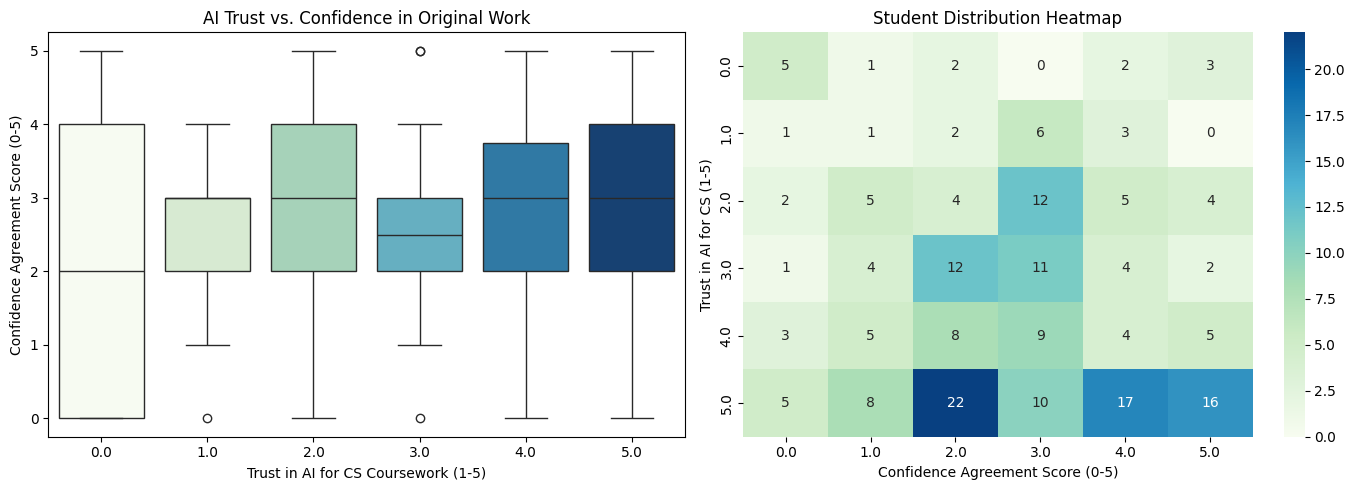

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Graph A: Boxplot (Fixed the palette name to 'GnBu')
sns.boxplot(
    data=df, x=cols[0], y=cols[1],
    hue=cols[0], palette='GnBu', legend=False, ax=ax[0]
)
ax[0].set(title='AI Trust vs. Confidence in Original Work',
          xlabel='Trust in AI for CS Coursework (1-5)',
          ylabel='Confidence Agreement Score (0-5)')

# Graph B: Heatmap
sns.heatmap(crosstab, annot=True, cmap='GnBu', fmt='d', ax=ax[1])
ax[1].set(title='Student Distribution Heatmap',
          xlabel='Confidence Agreement Score (0-5)',
          ylabel='Trust in AI for CS (1-5)')

plt.tight_layout()
plt.show()

**Null Hypothesis:** There is no correlation between a student's level of trust in AI for CS coursework and their agreement that AI does affect their confidence.

**Alternative Hypothesis:** There is a statistically significant correlation between the frequency of a student's use of AI and their agreement that AI doesn't impact their confidence.

**Spearman's Rank Correlation:** Since both variables are ranked numerical scales, Spearman's correlation is the best test to measure the strength of the relationship between the two variables

**Chi-Squared Test of Independence:** This test determines if there is a significant association between two categorical variables. We are testing to see if the "Agreement" rating is independent of the "CS Trust" rating.

In [14]:
# 1. Spearman Correlation
r, p_spear = spearmanr(df[cols[0]], df[cols[1]])

# 2. Chi-Squared Test
chi2, p_chi2, dof, _ = chi2_contingency(crosstab)

# Print cleanly formatted results
print("--- Statistical Results ---")
print(f"Spearman Correlation: r = {r:.3f}, p = {p_spear:.5f}")
print(f"Chi-Squared Test:     X² = {chi2:.3f}, p = {p_chi2:.5f}, dof = {dof}")

--- Statistical Results ---
Spearman Correlation: r = 0.094, p = 0.18275
Chi-Squared Test:     X² = 44.158, p = 0.01041, dof = 25


### **Results**
The Spearmant Correlation yielded a statistic of r being approximately equal to 0.094, with a p-value of 0.18275.

Because this p-value is greater than the significance level p = 0.05, we **fail to reject the null hypothesis** for a monotonic relationship. The correlation coefficient(r = 0.094) indicates a weak positive trend, not statistically significant. This means there is no "Straight-Line Rule" where more trust = more usage.

The Chi-Squared Test yielded a statistic of x^2 being approximately equal to 44.158 with a p-value of 0.01041.

Becuase this p-value is less than the significance level p = 0.05, we **reject the null hypothesis** of independence.



##**Conclusion**
Looking back at our core question--Does a student's level of trust in AI for CS impact their belief that AI doesn't affect their confidence?--the data shows a complex but statistically significant relationship.

Because the Chi-Squared test is significant but the Spearman correlation is not, it means the two variables are connected, but not in a simple upward or downward slope. This suggests that trusting AI does impact a student's trust in their own work, but the effect varies based on the specific student.

Instead of a uniform trend or pattern, students likely fall into clusters. For example, some students may trust AI as a helpful tool that supplements their learning(maintaing confidence), while others with the same high trust may see it as a crutch(low confidence). The significant Chi-Squared test proves the impact exists, but the insiginificant Spearman test proves that trusting AI does not uniformly impact a student's confidence across the board.